
# Series de tiempo financieras con Python y `yfinance`

## De AR, MA y ARMA a ARIMA y ARIMAX

### Objetivos

- Descargar y preparar precios financieros.
- Calcular precios ajustados y retornos logarítmicos.
- Evaluar estacionariedad con **ADF** y **KPSS**.
- Comprender y estimar modelos **AR**, **MA**, **ARMA** y **ARIMA**.
- Incorporar **variables exógenas (X)** mediante un modelo **ARIMAX**.
- Comparar pronósticos fuera de muestra.
- Entender cuándo tiene sentido usar factores de mercado como variables explicativas.

> **Nota financiera importante:** para modelamiento estadístico suele ser preferible trabajar con retornos o con transformaciones estacionarias, en lugar de modelar directamente precios no estacionarios.



## 1. Instalación de librerías



## 2. Librerías


In [97]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.options.display.float_format = "{:,.6f}".format


## 3. Activo financiero y factores externos

Trabajaremos con:

- **Activo objetivo:** `AAPL` — Apple.
- **Mercado:** `^GSPC` — S&P 500.
- **Tasa de interés:** `^TNX` — rendimiento del Treasury estadounidense a 10 años.
- **Dólar:** `DX-Y.NYB` — Dollar Index.

La lógica del modelo ARIMAX será:

$$
Y_t = \text{dinámica propia de la serie} + \beta_1 X_{1,t}+\beta_2 X_{2,t}+\cdots+\varepsilon_t
$$

donde:

- $Y_t$: retorno del activo.
- $X_t$: factores externos que pueden ayudar a explicar sus movimientos.


In [98]:

TICKER = "AAPL"
START = "2020-01-01"
END = None

tickers = [TICKER, "^GSPC", "^TNX", "DX-Y.NYB"]

raw = yf.download(
    tickers,
    start=START,
    end=END,
    auto_adjust=True,
    progress=False
)

raw.head()


Price          Close                                      High            \
Ticker          AAPL  DX-Y.NYB        ^GSPC     ^TNX      AAPL  DX-Y.NYB   
Date                                                                       
2020-01-02 72.271545 96.849998 3,257.850098 1.882000 72.331702 96.870003   
2020-01-03 71.568909 96.839996 3,234.850098 1.788000 72.326874 97.110001   
2020-01-06 72.139191 96.669998 3,246.280029 1.811000 72.177691 96.900002   
2020-01-07 71.799911 96.980003 3,237.179932 1.827000 72.403874 97.089996   
2020-01-08 72.954941 97.300003 3,253.050049 1.874000 73.255721 97.330002   

Price                                  Low                                  \
Ticker            ^GSPC     ^TNX      AAPL  DX-Y.NYB        ^GSPC     ^TNX   
Date                                                                         
2020-01-02 3,258.139893 1.903000 71.029923 96.430000 3,235.530029 1.851000   
2020-01-03 3,246.149902 1.840000 71.345130 96.709999 3,222.340088 1.786000   
2020-01-06 3,246.840088 1.816000 70.442792 96.540001 3,214.639893 1.766000   
2020-01-07 3,244.909912 1.828000 71.580942 96.620003 3,232.429932 1.797000   
2020-01-08 3,267.070068 1.876000 71.503975 96.820000 3,236.669922 1.802000   

Price           Open                                             Volume  \
Ticker          AAPL  DX-Y.NYB        ^GSPC     ^TNX               AAPL   
Date                                                                      
2020-01-02 71.282575 96.480003 3,244.669922 1.903000 135,480,400.000000   
2020-01-03 71.501534 96.790001 3,226.360107 1.828000 146,322,800.000000   
2020-01-06 70.693043 96.900002 3,217.550049 1.785000 118,387,200.000000   
2020-01-07 72.148812 96.650002 3,241.860107 1.797000 108,872,000.000000   
2020-01-08 71.503975 96.830002 3,238.590088 1.823000 132,079,200.000000   

Price                                              
Ticker     DX-Y.NYB                ^GSPC     ^TNX  
Date                                               
2020-01-02        0 3,459,930,000.000000 0.000000  
2020-01-03        0 3,484,700,000.000000 0.000000  
2020-01-06        0 3,702,460,000.000000 0.000000  
2020-01-07        0 3,435,910,000.000000 0.000000  
2020-01-08        0 3,726,840,000.000000 0.000000


## 4. Preparación de datos

Con `auto_adjust=True`, `Close` ya se encuentra ajustado por eventos corporativos como splits y dividendos cuando corresponde.

Extraeremos los precios de cierre y construiremos:

- Retorno logarítmico del activo.
- Retorno logarítmico del S&P 500.
- Cambio diario de la tasa a 10 años.
- Retorno logarítmico del índice dólar.


In [99]:

close = raw["Close"].copy()
close.columns = [str(c) for c in close.columns]

data = pd.DataFrame(index=close.index)

data["price"] = close[TICKER]
data["ret"] = np.log(close[TICKER]).diff()

data["market_ret"] = np.log(close["^GSPC"]).diff()
data["tnx_change"] = close["^TNX"].diff()
data["dollar_ret"] = np.log(close["DX-Y.NYB"]).diff()

data = data.dropna()

data.tail()


,price,ret,market_ret,tnx_change,dollar_ret
Date,,,,,
2026-09-03,328.209991,0.009952,0.010524,-0.034000,-0.005641
2026-09-04,319.970001,-0.025426,-0.003764,0.022000,0.001615
2026-09-08,316.220001,-0.011789,-0.005858,0.022000,-0.003232
2026-09-09,315.339996,-0.002787,-0.004854,0.031000,-0.000708
2026-09-10,326.570007,0.034993,-0.005865,0.107000,0.003517



## 5. Exploración visual

Primero observamos el precio. Después analizamos los retornos.

En activos financieros es habitual encontrar:

- precios con tendencia o comportamiento no estacionario;
- retornos fluctuando alrededor de una media relativamente estable;
- periodos de alta y baja volatilidad.


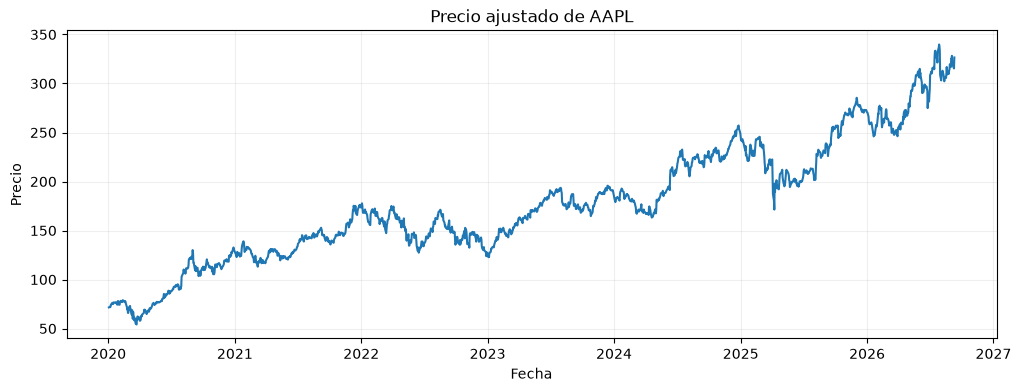

In [100]:

plt.figure(figsize=(12, 4))
plt.plot(data.index, data["price"])
plt.title(f"Precio ajustado de {TICKER}")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.grid(alpha=0.2)
plt.show()


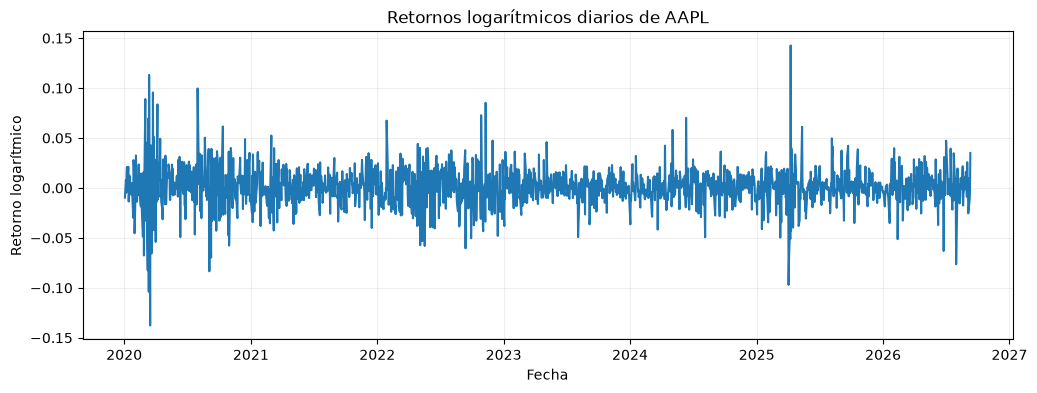

In [101]:

plt.figure(figsize=(12, 4))
plt.plot(data.index, data["ret"])
plt.title(f"Retornos logarítmicos diarios de {TICKER}")
plt.xlabel("Fecha")
plt.ylabel("Retorno logarítmico")
plt.grid(alpha=0.2)
plt.show()



## 6. Estadísticos descriptivos

Además de la media y la desviación estándar, conviene observar asimetría y curtosis.

Los retornos financieros suelen mostrar **colas más pesadas que una distribución normal**, por lo que los modelos lineales de media no capturan necesariamente toda la dinámica del riesgo.


In [102]:

summary = data[["ret", "market_ret", "tnx_change", "dollar_ret"]].describe().T
summary["skew"] = data[["ret", "market_ret", "tnx_change", "dollar_ret"]].skew()
summary["kurtosis"] = data[["ret", "market_ret", "tnx_change", "dollar_ret"]].kurtosis()

summary


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
ret,"1,678.000000",0.000898,0.019721,-0.137708,-0.008229,0.001139,0.011136,0.142617,-0.018653,6.329991
market_ret,"1,678.000000",0.000501,0.012799,-0.127652,-0.004758,0.000895,0.006709,0.090895,-0.641971,15.143023
tnx_change,"1,678.000000",0.001820,0.059967,-0.322000,-0.033000,0.002000,0.037000,0.269000,-0.092604,1.800269
dollar_ret,"1,678.000000",0.000008,0.004377,-0.021394,-0.002496,0.000096,0.002580,0.016389,-0.209687,1.703970



# 7. Estacionariedad: ADF y KPSS

Antes de estimar ARIMA debemos estudiar si la serie es estacionaria.

### ADF — Augmented Dickey-Fuller

- $H_0$: existe raíz unitaria → la serie no es estacionaria.
- Si `p-value < 0.05`, existe evidencia para rechazar $H_0$.

### KPSS

- $H_0$: la serie es estacionaria.
- Si `p-value < 0.05`, existe evidencia contra la estacionariedad.

Usarlos conjuntamente mejora la interpretación.


In [103]:

def stationarity_tests(series, name="Serie"):
    s = series.dropna()

    adf = adfuller(s, autolag="AIC")
    kpss_result = kpss(s, regression="c", nlags="auto")

    result = pd.DataFrame({
        "Prueba": ["ADF", "KPSS"],
        "Estadístico": [adf[0], kpss_result[0]],
        "p-value": [adf[1], kpss_result[1]],
        "Interpretación_H0": [
            "H0: raíz unitaria / no estacionaria",
            "H0: estacionaria"
        ]
    })

    print(f"Pruebas de estacionariedad: {name}")
    return result

stationarity_tests(np.log(data["price"]), "Log-precio")


Pruebas de estacionariedad: Log-precio


,Prueba,Estadístico,p-value,Interpretación_H0
0,ADF,-1.331658,0.614567,H0: raíz unitaria / no estacionaria
1,KPSS,5.370007,0.010000,H0: estacionaria


In [104]:

stationarity_tests(data["ret"], "Retorno logarítmico")


Pruebas de estacionariedad: Retorno logarítmico


,Prueba,Estadístico,p-value,Interpretación_H0
0,ADF,-13.708979,0.000000,H0: raíz unitaria / no estacionaria
1,KPSS,0.058275,0.100000,H0: estacionaria



### Interpretación esperada

En muchos activos:

- el **log-precio** no será estacionario;
- el **retorno logarítmico** sí será estacionario.

Esto explica la lógica de ARIMA:

$$
ARIMA(p,d,q)
$$

donde:

- $p$: componente autorregresivo.
- $d$: número de diferenciaciones.
- $q$: componente de media móvil.

Cuando ya trabajamos con retornos, normalmente ya hemos realizado una transformación equivalente a una primera diferencia del log-precio. Por ello, al modelar retornos suele utilizarse $d=0$.



# 8. ACF y PACF

Las funciones de autocorrelación ayudan a inspeccionar dependencia temporal:

- **ACF:** correlación entre la serie y sus propios rezagos.
- **PACF:** correlación parcial, controlando por rezagos intermedios.

Como regla pedagógica:

- PACF puede ayudar a orientar $p$ en un AR.
- ACF puede ayudar a orientar $q$ en un MA.

En aplicaciones reales, la selección final debe apoyarse también en criterios como AIC/BIC y validación fuera de muestra.


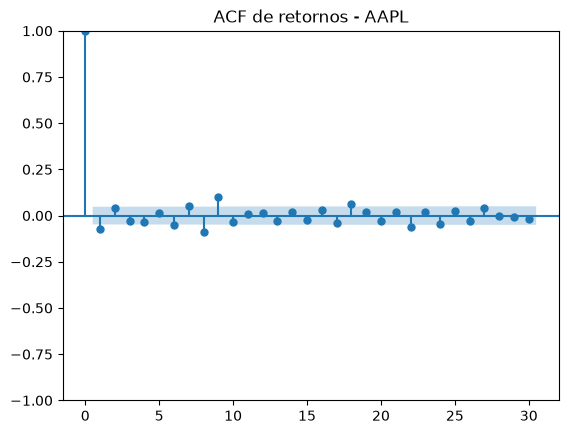

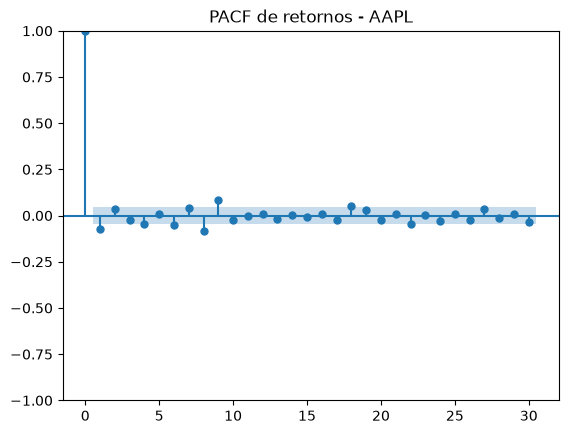

In [105]:

fig = plot_acf(data["ret"], lags=30)
plt.title(f"ACF de retornos - {TICKER}")
plt.show()

fig = plot_pacf(data["ret"], lags=30, method="ywm")
plt.title(f"PACF de retornos - {TICKER}")
plt.show()



# 9. Separación entrenamiento / prueba

No evaluaremos el modelo con los mismos datos utilizados para estimarlo.

Reservaremos aproximadamente el último 20 % de observaciones para evaluar pronósticos fuera de muestra.


In [106]:
target = data["ret"].copy()

split = int(len(target) * 0.80)

train_y = target.iloc[:split]
test_y = target.iloc[split:]

print("Entrenamiento:", train_y.index.min().date(), "\u2192", train_y.index.max().date())
print("Prueba:", test_y.index.min().date(), "\u2192", test_y.index.max().date())
print("N train:", len(train_y))
print("N test :", len(test_y))

# statsmodels >= 0.15 exige que un DatetimeIndex tenga frecuencia asignada
# al llamar a .forecast(); el indice que entrega yfinance no la tiene
# (por los fines de semana/feriados sin filas). Reseteamos el indice de
# train_y a uno numerico simple antes de ajustar el modelo para evitar
# "ValueError: No supported index is available". test_y mantiene sus
# fechas reales, se usan mas abajo para graficar y reasignarlas al forecast.
train_y = train_y.reset_index(drop=True)


Entrenamiento: 2020-01-03 → 2025-05-07
Prueba: 2025-05-08 → 2026-09-10
N train: 1342
N test : 336



# 10. Modelos AR, MA y ARMA

Podemos expresar estos modelos mediante la clase `ARIMA`:

- **AR(p)** = ARIMA(p, 0, 0)
- **MA(q)** = ARIMA(0, 0, q)
- **ARMA(p,q)** = ARIMA(p, 0, q)

Empezaremos con especificaciones sencillas para comprender la estructura.


In [107]:

model_ar = ARIMA(train_y, order=(1, 0, 0)).fit()
model_ma = ARIMA(train_y, order=(0, 0, 1)).fit()
model_arma = ARIMA(train_y, order=(1, 0, 1)).fit()

comparison_ic = pd.DataFrame({
    "Modelo": ["AR(1)", "MA(1)", "ARMA(1,1)"],
    "AIC": [model_ar.aic, model_ma.aic, model_arma.aic],
    "BIC": [model_ar.bic, model_ma.bic, model_arma.bic]
})

comparison_ic.sort_values("AIC")


,Modelo,AIC,BIC
0,AR(1),"-6,618.842205","-6,603.236456"
1,MA(1),"-6,618.007497","-6,602.401748"
2,"ARMA(1,1)","-6,617.952102","-6,597.144437"



## ¿Qué significa el AIC?

El **Akaike Information Criterion** penaliza modelos excesivamente complejos.

$$
AIC = -2\log(L) + 2k
$$

Entre modelos estimados sobre la misma muestra y variable objetivo, un **AIC menor** suele ser preferible.

No obstante, un AIC bajo no garantiza el mejor pronóstico. Por eso también realizaremos evaluación fuera de muestra.



# 11. Selección sencilla de ARIMA por AIC

Probamos distintas combinaciones de $p$ y $q$.

Como nuestra variable objetivo es el retorno, usaremos $d=0$.

> Para un curso introductorio, este grid pequeño es suficiente. En proyectos reales pueden evaluarse más órdenes y criterios adicionales.


In [108]:

results = []

for p in range(0, 4):
    for q in range(0, 4):
        try:
            model = ARIMA(train_y, order=(p, 0, q)).fit()
            results.append({
                "p": p,
                "d": 0,
                "q": q,
                "AIC": model.aic,
                "BIC": model.bic
            })
        except:
            pass

grid_results = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
grid_results.head(10)


,p,d,q,AIC,BIC
0,1,0,3,"-6,621.975746","-6,590.764249"
1,1,0,0,"-6,618.842205","-6,603.236456"
2,2,0,0,"-6,618.180617","-6,597.372952"
3,0,0,1,"-6,618.007497","-6,602.401748"
4,1,0,1,"-6,617.952102","-6,597.144437"
5,0,0,3,"-6,617.775102","-6,591.765520"
6,0,0,2,"-6,617.746454","-6,596.938789"
7,3,0,0,"-6,616.891974","-6,590.882392"
8,1,0,2,"-6,616.182235","-6,590.172653"
9,2,0,1,"-6,615.765141","-6,589.755559"


In [109]:

best_p = int(grid_results.loc[0, "p"])
best_q = int(grid_results.loc[0, "q"])

print(f"Mejor especificación por AIC: ARIMA({best_p}, 0, {best_q})")

best_arima = ARIMA(train_y, order=(best_p, 0, best_q)).fit()
print(best_arima.summary())


Mejor especificación por AIC: ARIMA(1, 0, 3)
                               SARIMAX Results                                
Dep. Variable:                    ret   No. Observations:                 1342
Model:                 ARIMA(1, 0, 3)   Log Likelihood                3316.988
Date:                Thu, 10 Sep 2026   AIC                          -6621.976
Time:                        23:53:19   BIC                          -6590.764
Sample:                             0   HQIC                         -6610.284
                               - 1342                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.001      1.099      0.272      -0.000       0.002
ar.L1         -0.8735      0.058    -14.938      0.000      -0.988      -0.759
ma.L1  


# 12. Pronóstico ARIMA

Generaremos pronósticos sobre el periodo de prueba.

En retornos financieros diarios, obtener una gran capacidad predictiva es difícil. El objetivo de este ejemplo es comprender correctamente el proceso de modelamiento y evaluación, no asumir que un ARIMA simple puede anticipar consistentemente el mercado.


In [110]:

pred_arima = best_arima.forecast(steps=len(test_y))
pred_arima.index = test_y.index

mae_arima = mean_absolute_error(test_y, pred_arima)
rmse_arima = np.sqrt(mean_squared_error(test_y, pred_arima))

print("MAE ARIMA :", mae_arima)
print("RMSE ARIMA:", rmse_arima)


MAE ARIMA : 0.011039783197893758
RMSE ARIMA: 0.015724239434858046


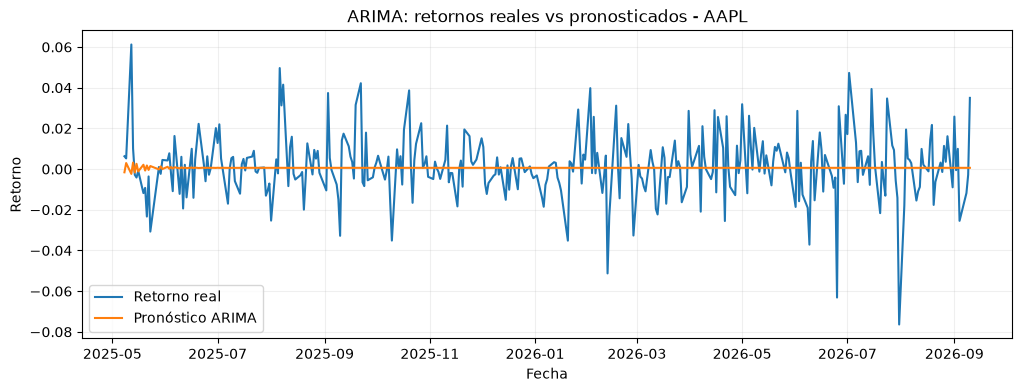

In [111]:

plt.figure(figsize=(12, 4))
plt.plot(test_y.index, test_y, label="Retorno real")
plt.plot(pred_arima.index, pred_arima, label="Pronóstico ARIMA")
plt.title(f"ARIMA: retornos reales vs pronosticados - {TICKER}")
plt.xlabel("Fecha")
plt.ylabel("Retorno")
plt.legend()
plt.grid(alpha=0.2)
plt.show()



# 13. ¿Por qué incorporar factores X?

Un ARIMA puro utiliza principalmente la dinámica histórica de $Y_t$.

En finanzas, podemos plantear que el retorno de una acción también depende de factores externos:

$$
r_{i,t}
=
\text{ARIMA}
+
\beta_1 r_{m,t}
+
\beta_2 \Delta Yield_t
+
\beta_3 r_{USD,t}
+
\varepsilon_t
$$

Por ejemplo:

- `market_ret`: movimiento general del mercado.
- `tnx_change`: cambio en la tasa del Treasury a 10 años.
- `dollar_ret`: movimiento del dólar.

Estas variables se denominan **exógenas** o **regresores externos**.

El modelo se suele denominar **ARIMAX**. En `statsmodels` podemos estimarlo utilizando `SARIMAX`, aunque no incorporemos estacionalidad.


In [112]:
features = ["market_ret", "tnx_change", "dollar_ret"]

X = data[features].copy()

train_X = X.iloc[:split]
test_X = X.iloc[split:]

# Mismo motivo que en train_y: SARIMAX exige que endog y exog tengan el
# mismo tipo de indice (ValueError: "The indices for endog and exog are
# not aligned" si no). Reseteamos train_X al mismo RangeIndex que
# train_y, y test_X continua desde donde termina train_X para que
# coincida con el indice que SARIMAX espera al generar el forecast.
train_X = train_X.reset_index(drop=True)
test_X = test_X.reset_index(drop=True)
test_X.index = test_X.index + len(train_X)

train_X.head()


,market_ret,tnx_change,dollar_ret
0,-0.007085,-0.094000,-0.000103
1,0.003527,0.023000,-0.001757
2,-0.002807,0.016000,0.003202
3,0.004890,0.047000,0.003294
4,0.006633,-0.016000,0.001540



## 14. Estandarización de las X

Las variables externas tienen escalas diferentes. Para facilitar la interpretación numérica y mejorar la estabilidad, estandarizaremos utilizando **solo información del periodo de entrenamiento**.

Esto evita *data leakage*.


In [113]:

mu = train_X.mean()
sigma = train_X.std()

train_X_std = (train_X - mu) / sigma
test_X_std = (test_X - mu) / sigma

train_X_std.describe().T


,count,mean,std,min,25%,50%,75%,max
market_ret,"1,342.000000",-0.000000,1.000000,-9.299468,-0.419798,0.035251,0.492232,6.569562
tnx_change,"1,342.000000",0.000000,1.000000,-5.085517,-0.576874,0.004376,0.601340,4.198829
dollar_ret,"1,342.000000",0.000000,1.000000,-4.737242,-0.562037,0.017415,0.586682,3.622377



# 15. ARIMAX

Utilizaremos el mismo orden $(p,0,q)$ seleccionado anteriormente, pero ahora agregando variables exógenas.


In [114]:

model_arimax = SARIMAX(
    train_y,
    exog=train_X_std,
    order=(best_p, 0, best_q),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(model_arimax.summary())


                               SARIMAX Results                                
Dep. Variable:                    ret   No. Observations:                 1342
Model:               SARIMAX(1, 0, 3)   Log Likelihood                3965.790
Date:                Thu, 10 Sep 2026   AIC                          -7913.580
Time:                        23:53:19   BIC                          -7866.790
Sample:                             0   HQIC                         -7896.049
                               - 1342                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0014      0.001      1.902      0.057   -4.25e-05       0.003
market_ret     0.0165      0.000     63.186      0.000       0.016       0.017
tnx_change    -0.0008      0.000     -2.319      0.0


### Interpretación de los coeficientes X

Observa en el resumen:

- signo del coeficiente;
- magnitud;
- `p-value`.

Por ejemplo:

- coeficiente positivo de `market_ret` → el activo tiende a moverse en la misma dirección que el mercado;
- coeficiente negativo ante `tnx_change` → aumentos de tasas se asociarían con menores retornos, manteniendo constantes los demás factores;
- un `p-value` alto indica que la evidencia estadística para ese factor es débil dentro de esta especificación.

Esto **no demuestra causalidad**. Es una relación condicional dentro del modelo.


In [115]:

pred_arimax = model_arimax.get_forecast(
    steps=len(test_y),
    exog=test_X_std
).predicted_mean

pred_arimax.index = test_y.index

mae_arimax = mean_absolute_error(test_y, pred_arimax)
rmse_arimax = np.sqrt(mean_squared_error(test_y, pred_arimax))

print("MAE ARIMAX :", mae_arimax)
print("RMSE ARIMAX:", rmse_arimax)


MAE ARIMAX : 0.010279119268120758
RMSE ARIMAX: 0.014547333467520683



# 16. Comparación ARIMA vs ARIMAX

Si las variables X contienen información útil, ARIMAX podría mejorar el desempeño fuera de muestra.

Pero **agregar más variables no garantiza un mejor modelo**. Las X pueden introducir ruido, multicolinealidad o información poco estable.


In [116]:

evaluation = pd.DataFrame({
    "Modelo": ["ARIMA", "ARIMAX"],
    "MAE": [mae_arima, mae_arimax],
    "RMSE": [rmse_arima, rmse_arimax]
})

evaluation


,Modelo,MAE,RMSE
0,ARIMA,0.011040,0.015724
1,ARIMAX,0.010279,0.014547


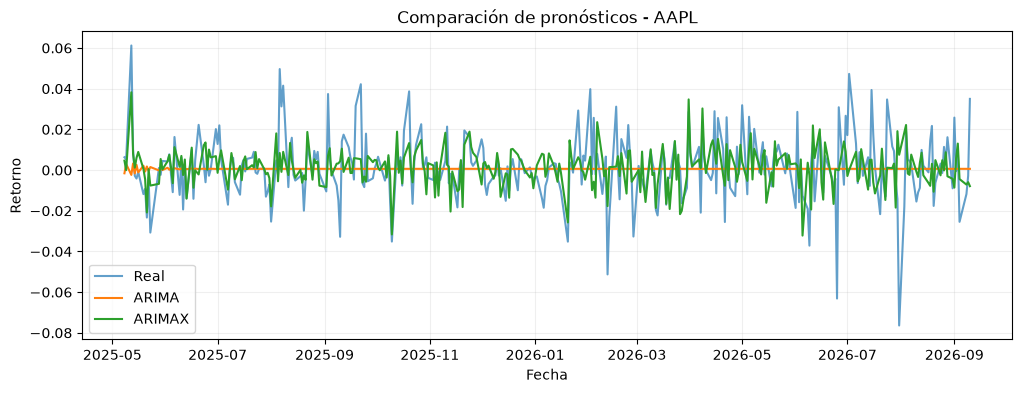

In [117]:

plt.figure(figsize=(12, 4))
plt.plot(test_y.index, test_y, label="Real", alpha=0.7)
plt.plot(pred_arima.index, pred_arima, label="ARIMA")
plt.plot(pred_arimax.index, pred_arimax, label="ARIMAX")
plt.title(f"Comparación de pronósticos - {TICKER}")
plt.xlabel("Fecha")
plt.ylabel("Retorno")
plt.legend()
plt.grid(alpha=0.2)
plt.show()



# 17. Comparación con un benchmark ingenuo

En finanzas siempre conviene comparar contra una referencia sencilla.

Para retornos diarios, un benchmark razonable es:

$$
\hat r_{t+1}=0
$$

Es decir, asumir retorno esperado diario igual a cero.

Si un modelo sofisticado no supera de manera consistente a una referencia simple, debemos ser cautelosos con su utilidad predictiva.


In [118]:

pred_naive = pd.Series(0.0, index=test_y.index)

mae_naive = mean_absolute_error(test_y, pred_naive)
rmse_naive = np.sqrt(mean_squared_error(test_y, pred_naive))

evaluation_full = pd.DataFrame({
    "Modelo": ["Naive: retorno = 0", "ARIMA", "ARIMAX"],
    "MAE": [mae_naive, mae_arima, mae_arimax],
    "RMSE": [rmse_naive, rmse_arima, rmse_arimax]
}).sort_values("RMSE")

evaluation_full


,Modelo,MAE,RMSE
2,ARIMAX,0.010279,0.014547
1,ARIMA,0.011040,0.015724
0,Naive: retorno = 0,0.011074,0.015727



# 18. Precaución importante al usar variables exógenas

En la evaluación anterior conocemos los valores de `market_ret`, `tnx_change` y `dollar_ret` del periodo de prueba porque son datos históricos.

Sin embargo, para realizar un **pronóstico verdaderamente futuro**, los valores futuros de esas X todavía no existen.

Por tanto, un ARIMAX operativo requiere alguna de estas alternativas:

1. variables cuya trayectoria futura ya sea conocida;
2. pronósticos independientes de las X;
3. escenarios hipotéticos;
4. variables rezagadas disponibles al momento de realizar la predicción.

Esta distinción es fundamental para evitar una evaluación artificialmente optimista.



# 19. Versión más realista: factores rezagados

Si queremos pronosticar el retorno de mañana utilizando únicamente información disponible hoy, podemos utilizar:

$$
X_{t-1}
$$

en lugar de $X_t$.

Así evitamos utilizar información contemporánea que todavía no conoceríamos al momento de emitir el pronóstico.


In [119]:
lagged = data.copy()

for col in features:
    lagged[f"{col}_lag1"] = lagged[col].shift(1)

lagged = lagged.dropna()

lag_features = [f"{col}_lag1" for col in features]

y_lag = lagged["ret"]
X_lag = lagged[lag_features]

split_lag = int(len(lagged) * 0.80)

train_y_lag = y_lag.iloc[:split_lag]
test_y_lag = y_lag.iloc[split_lag:]

train_X_lag = X_lag.iloc[:split_lag]
test_X_lag = X_lag.iloc[split_lag:]

# Mismo motivo que en las secciones 12 y 15: reseteamos el indice de
# train_y_lag/train_X_lag a RangeIndex antes de ajustar el modelo, para
# evitar "No supported index is available" al hacer .get_forecast() con
# statsmodels >= 0.15. test_y_lag mantiene sus fechas reales (se usan
# para graficar y reasignarlas al forecast); test_X_lag continua la
# numeracion justo donde termina train_X_lag para quedar alineado.
train_y_lag = train_y_lag.reset_index(drop=True)
train_X_lag = train_X_lag.reset_index(drop=True)
test_X_lag = test_X_lag.reset_index(drop=True)
test_X_lag.index = test_X_lag.index + len(train_X_lag)

mu_lag = train_X_lag.mean()
sigma_lag = train_X_lag.std()

train_X_lag_std = (train_X_lag - mu_lag) / sigma_lag
test_X_lag_std = (test_X_lag - mu_lag) / sigma_lag


In [120]:

model_arimax_lag = SARIMAX(
    train_y_lag,
    exog=train_X_lag_std,
    order=(best_p, 0, best_q),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

pred_arimax_lag = model_arimax_lag.get_forecast(
    steps=len(test_y_lag),
    exog=test_X_lag_std
).predicted_mean

pred_arimax_lag.index = test_y_lag.index

mae_arimax_lag = mean_absolute_error(test_y_lag, pred_arimax_lag)
rmse_arimax_lag = np.sqrt(mean_squared_error(test_y_lag, pred_arimax_lag))

print("MAE ARIMAX con X rezagadas :", mae_arimax_lag)
print("RMSE ARIMAX con X rezagadas:", rmse_arimax_lag)


MAE ARIMAX con X rezagadas : 0.011297061825511736
RMSE ARIMAX con X rezagadas: 0.015862706751067934



# 20. Conclusiones

### AR
Modela el valor actual a partir de valores pasados de la misma serie.

### MA
Modela la serie utilizando errores pasados.

### ARMA
Combina componentes AR y MA para series estacionarias.

### ARIMA
Agrega diferenciación y permite trabajar con series originalmente no estacionarias.

### ARIMAX
Extiende ARIMA incorporando factores externos $X$.

En un contexto financiero, estas X pueden representar:

- retorno del mercado;
- tasas de interés;
- tipo de cambio;
- commodities;
- índices sectoriales;
- factores macroeconómicos;
- variables propias de la empresa.

### Idea central

No debemos preguntar únicamente:

> “¿Qué dicen los valores pasados de la acción?”

También podemos preguntar:

> “¿Qué parte de su comportamiento puede explicarse por su propia historia y qué parte está asociada a factores externos?”

Esa es precisamente la transición conceptual de **ARIMA a ARIMAX**.
